# 02 Noiseless Echo Circuits
Build `U`, then `U dagger`, and verify return to the initial state. This is the basic Loschmidt echo idea for a linear chain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

In [16]:
num_qubits = 4
cycles = 1

In [22]:
q_1 = 2

if q_1 ==0:
    print("Error: index 0 is for ancilla in OTOC evolution")

qubits = cirq.LineQubit.range(num_qubits)
num_qubits = len(qubits)

c = cirq.Circuit(
    cirq.X(qubits[q_1]),
    [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == q_1],
    )
print("Initial circuit: ")
print(c)

Initial circuit: 
0: ───Y^0.5───

1: ───Y^0.5───

2: ───X───────

3: ───Y^0.5───


In [25]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit """

    if not num_qubits % 2 == 0:
        return print("Total number of qubits has to be even") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    pow_gate = len(powers)
    n_gate = len(single_qubit_gate)
    c = cirq.Circuit()

    rnd_pow = rng.choice(pow_gate, (num_qubits, cycles))
    rnd_gate = rng.choice(n_gate, (num_qubits, cycles))

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(pow_gate)
            c.append(gate(q)**power)

        # Entangling layer: even bonds
        for i in range(0, len(qubits) - 1, 2):
            c.append(cirq.CZ(qubits[i], qubits[i + 1]))

        # Entangling layer: odd bonds
        for i in range(1, len(qubits) - 1, 2):
            c.append(cirq.CZ(qubits[i], qubits[i + 1]))
    return c

In [26]:
print("U|psi>|1> for a given depth, here = 1")
depth = 1
seed = 3
U_t = simple_random_circuit(qubits, depth, seed)
c.append(U_t)
print(c)

U|psi>|1> for a given depth, here = 1
0: ───Y^0.5───X^0───@───────
                    │
1: ───Y^0.5───X^0───@───@───
                        │
2: ───X───────Y^0───@───@───
                    │
3: ───Y^0.5───X^0───@───────


In [27]:
U_t_dagger = cirq.inverse(U_t)
print(f"U^dagger U|psi>|1> for a given depth, here = {depth}")
c.append(U_t_dagger)
print(c)

U^dagger U|psi>|1> for a given depth, here = 1
0: ───Y^0.5───X^0───@───────────@───X^0───
                    │           │
1: ───Y^0.5───X^0───@───@───@───@───X^0───
                        │   │
2: ───X───────Y^0───@───@───@───@───Y^0───
                    │           │
3: ───Y^0.5───X^0───@───────────@───X^0───


In [28]:
print("Measuring the chosen qubit")
c.append(cirq.measure(qubits[q_1], key="z"))
print(c)

Measuring the chosen qubit
0: ───Y^0.5───X^0───@───────────@───X^0────────────
                    │           │
1: ───Y^0.5───X^0───@───@───@───@───X^0────────────
                        │   │
2: ───X───────Y^0───@───@───@───@───Y^0───M('z')───
                    │           │
3: ───Y^0.5───X^0───@───────────@───X^0────────────


In [29]:
print("Perfect echo simulation")
sampler = cirq.Simulator()
results = sampler.run(c, repetitions=1000)

Perfect echo simulation


<Axes: title={'center': 'Echo checking for a noiseless circuit \ndepth = 1'}, xlabel='qubit state', ylabel='result count'>

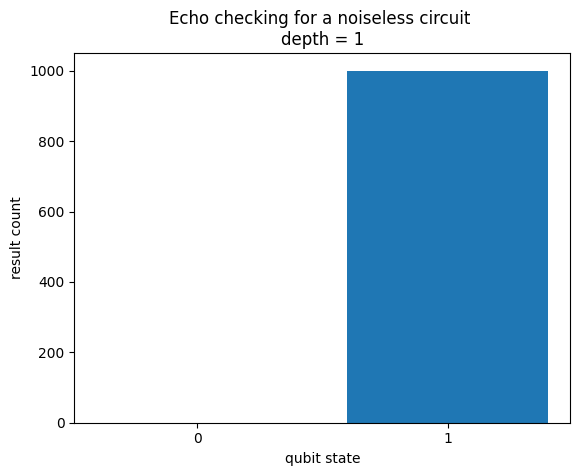

In [30]:
#counts = results.histogram(key="z")
#cirq.plot_state_histogram(counts, plt.subplot())
cirq.plot_state_histogram(results, 
                          plt.subplot(),
                          title="Echo checking for a noiseless circuit \n" + f"depth = {depth}")

## Preparing the function Echo test

In [31]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit """

    if not num_qubits % 2 == 0:
        return print("Total number of qubits has to be even") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    pow_gate = len(powers)
    n_gate = len(single_qubit_gate)
    c = cirq.Circuit()

    rnd_pow = rng.choice(pow_gate, (num_qubits, depth))
    rnd_gate = rng.choice(n_gate, (num_qubits, depth))

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(pow_gate)
            c.append(gate(q)**power)

        # Entangling layer: even bonds
        for i in range(0, len(qubits) - 1, 2):
            c.append(cirq.CZ(qubits[i], qubits[i + 1]))

        # Entangling layer: odd bonds
        for i in range(1, len(qubits) - 1, 2):
            c.append(cirq.CZ(qubits[i], qubits[i + 1]))
    return c

In [32]:
def noiseless_echo_circuit(qubits, depth, q_1, seed):

    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[q_1]), # Making q_1 = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == q_1],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    U_t_dagger = cirq.inverse(U_t)
    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[q_1], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    counts = results.measurements["z"]
    return counts

In [33]:
num_qubits = 4
qubits = cirq.LineQubit.range(num_qubits)
depths = 10
sampler = cirq.Simulator()
seed = 3

z_avg = np.zeros(depths)
for layer in range(depths):
    count = 0
    for k in range(num_qubits):
        count += np.mean(noiseless_echo_circuit(qubits, layer, k, seed), axis = 0)[0]
    count /= num_qubits
    z_avg[layer] = count

Text(0, 0.5, '$\\langle Counts \\rangle_{q_{1}}$')

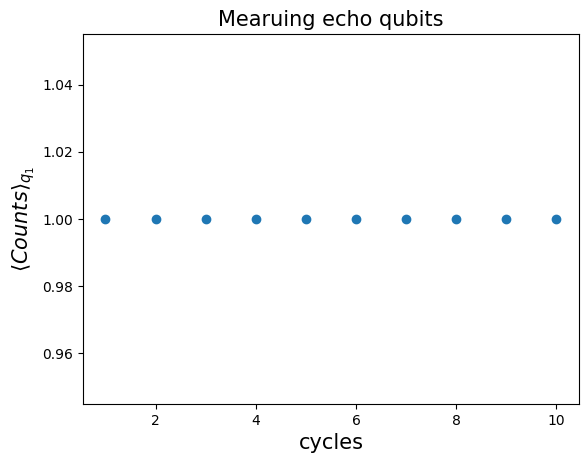

In [34]:
plt.plot(range(1,depths+1), z_avg, "o")
plt.title("Mearuing echo qubits", fontsize= 15)
plt.xlabel("cycles", fontsize= 15)
plt.ylabel(r"$\langle Counts \rangle_{q_{1}}$", fontsize= 15)

In [ ]:
import pathlib, sys
sys.path.append(str(pathlib.Path.cwd().parent))

import cirq
from src.circuits import make_line_qubits, make_simple_entangling_circuit, make_echo_circuit, add_measurements
from src.observables import bitstring_histogram, estimate_return_probability

In [ ]:
qubits = make_line_qubits(3)
U = make_simple_entangling_circuit(qubits, depth=4)
echo = add_measurements(make_echo_circuit(U, qubits), qubits)
result = cirq.Simulator().run(echo, repetitions=1000)
bitstring_histogram(result), estimate_return_probability(result, len(qubits))

In ideal simulation, `U` followed by `U dagger` should return to `|000>`. Real hardware would not be perfect.